In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [5]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/mental_health_tech_ml.csv")

df_ml.head()

,Age,self_employed,family_history,treatment,remote_work,tech_company,obs_consequence,Age__missing,Gender__missing,state__missing,self_employed__missing,work_interfere__missing,Gender_male,Country_Austria,"Country_Bahamas, The",Country_Belgium,Country_Bosnia and Herzegovina,Country_Brazil,Country_Bulgaria,Country_Canada,Country_China,Country_Colombia,Country_Costa Rica,Country_Croatia,Country_Czech Republic,Country_Denmark,Country_Finland,Country_France,Country_Georgia,Country_Germany,Country_Greece,Country_Hungary,Country_India,Country_Ireland,Country_Israel,Country_Italy,Country_Japan,Country_Latvia,Country_Mexico,Country_Moldova,Country_Netherlands,Country_New Zealand,Country_Nigeria,Country_Norway,Country_Philippines,Country_Poland,Country_Portugal,Country_Romania,Country_Russia,Country_Singapore,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_United Kingdom,Country_United States,Country_Uruguay,Country_Zimbabwe,state_AZ,state_CA,state_CO,state_CT,state_DC,state_FL,state_GA,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_NC,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37.0,0.0,0,1,0,1,0,0,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,True,False,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,True,True,False,False,False,False,True
1,44.0,0.0,0,0,0,0,0,0,0,0,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False
2,32.0,0.0,0,0,0,1,0,0,0,1,1,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [6]:
# Target variable: work interference + treatment
# Create a binary target variable for work interference
# 0 --> no interference, 1 --> interference (rarely/sometimes/often)
df = df_ml.copy()

df["work_interfere_binary"] = (
    df[[
        "work_interfere_Often",
        "work_interfere_Rarely",
        "work_interfere_Sometimes"
    ]].sum(axis=1) > 0
).astype(int)

In [7]:
# Create a combined target variable with three classes:
# 0 --> no interference, 1 --> interference but no treatment, 2 --> interference
df["combined_target"] = None

# No interference
df.loc[df["work_interfere_binary"] == 0, "combined_target"] = 0

# Interference but no treatment
df.loc[
    (df["work_interfere_binary"] == 1) &
    (df["treatment"] == 0),
    "combined_target"
] = 1

# Interference + treatment
df.loc[
    (df["work_interfere_binary"] == 1) &
    (df["treatment"] == 1),
    "combined_target"
] = 2

df["combined_target"] = df["combined_target"].astype(int)

In [8]:
# Drop target variables
X = df.drop(columns=[
    "combined_target",
    "treatment",
    "work_interfere_Often",
    "work_interfere_Rarely",
    "work_interfere_Sometimes",
    "work_interfere__missing",
    "work_interfere_binary"
])

y = df["combined_target"]

In [9]:
# Result means:
# 17% employees have no work interference (class 0), meaning they do not experience mental health issues that interfere with work.
# 83% employees have work interference (class 1 + class 2)
# 35% employees experience work interference but do not seek treatment (class 1)
df["combined_target"].value_counts(normalize=True)

combined_target
2    0.482129
1    0.348689
0    0.169182
Name: proportion, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)



              precision    recall  f1-score   support

           0       0.23      0.44      0.31        43
           1       0.52      0.41      0.46        88
           2       0.77      0.65      0.71       121

    accuracy                           0.53       252
   macro avg       0.51      0.50      0.49       252
weighted avg       0.59      0.53      0.55       252

Macro F1: 0.49119017279669097
Weighted F1: 0.5526390831625546


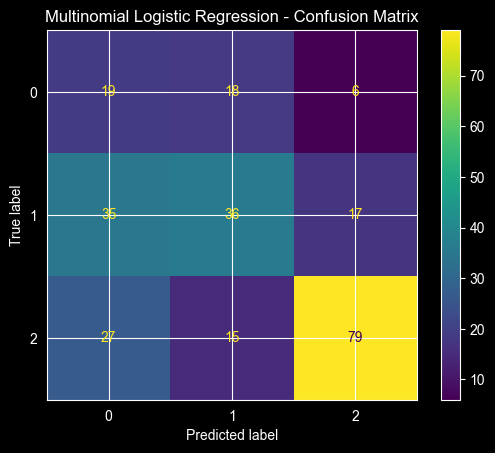

In [27]:
# Evaluation
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.35      0.21      0.26        43
           1       0.49      0.60      0.54        88
           2       0.74      0.72      0.73       121

    accuracy                           0.59       252
   macro avg       0.52      0.51      0.51       252
weighted avg       0.58      0.59      0.58       252

Random Forest Macro F1: 0.5099064548504503
Random Forest Weighted F1: 0.5829415803501855


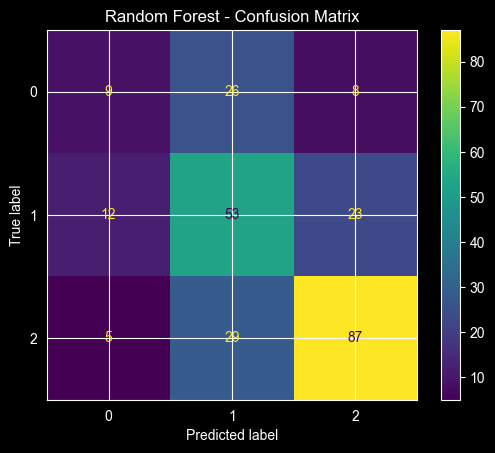

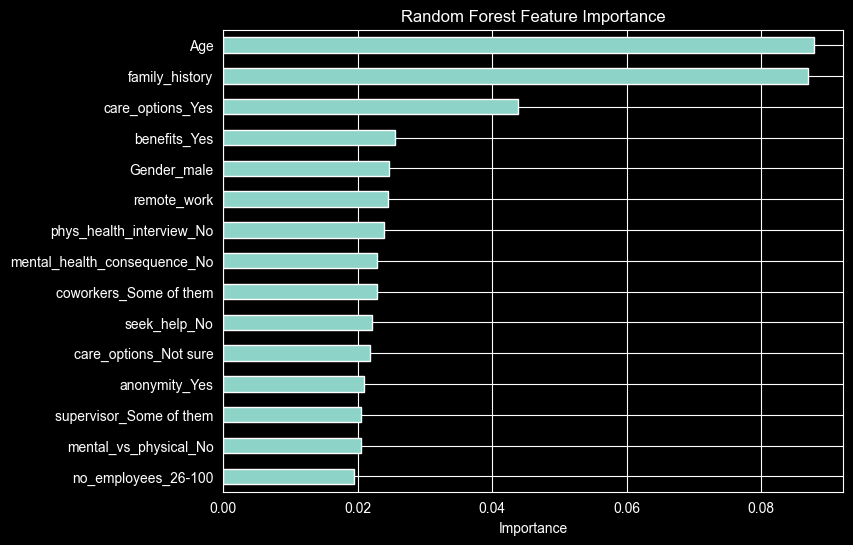

In [12]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print(classification_report(y_test, y_pred_rf))

macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Macro F1:", macro_f1_rf)
print("Random Forest Weighted F1:", weighted_f1_rf)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

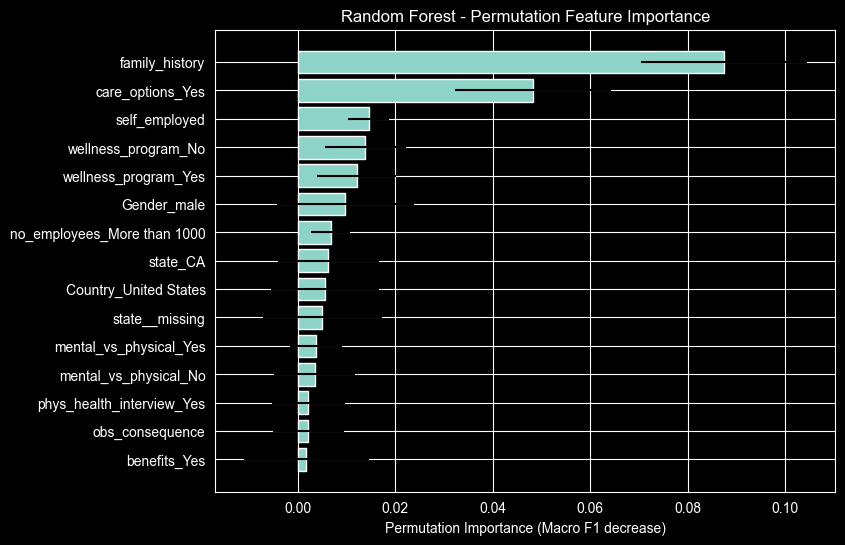

In [13]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_df.head(15)

top_features = perm_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Random Forest - Permutation Feature Importance")
plt.show()

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",   # multiclass probabilities
    num_class=3,                  # classes: 0, 1, 2
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.43      0.21      0.28        43
           1       0.53      0.66      0.59        88
           2       0.75      0.76      0.76       121

    accuracy                           0.63       252
   macro avg       0.57      0.54      0.54       252
weighted avg       0.62      0.63      0.62       252

XGBoost Macro F1: 0.5424280444667265
XGBoost Weighted F1: 0.6171920954769978


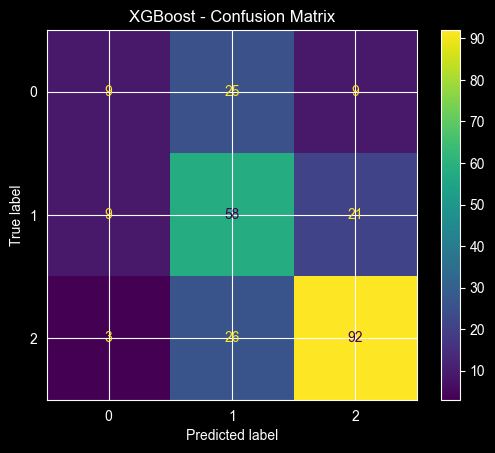

In [15]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_xgb))

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Macro F1:", macro_f1_xgb)
print("XGBoost Weighted F1:", weighted_f1_xgb)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

family_history                  0.053914
care_options_Yes                0.027736
Gender_male                     0.016441
Country_United States           0.016365
state_TN                        0.015573
leave_Somewhat difficult        0.014987
mental_health_consequence_No    0.014714
benefits_Yes                    0.014565
remote_work                     0.014550
no_employees_500-1000           0.014459
obs_consequence                 0.014349
state__missing                  0.014191
wellness_program_Yes            0.013803
leave_Very difficult            0.013627
benefits_No                     0.013554
dtype: float32


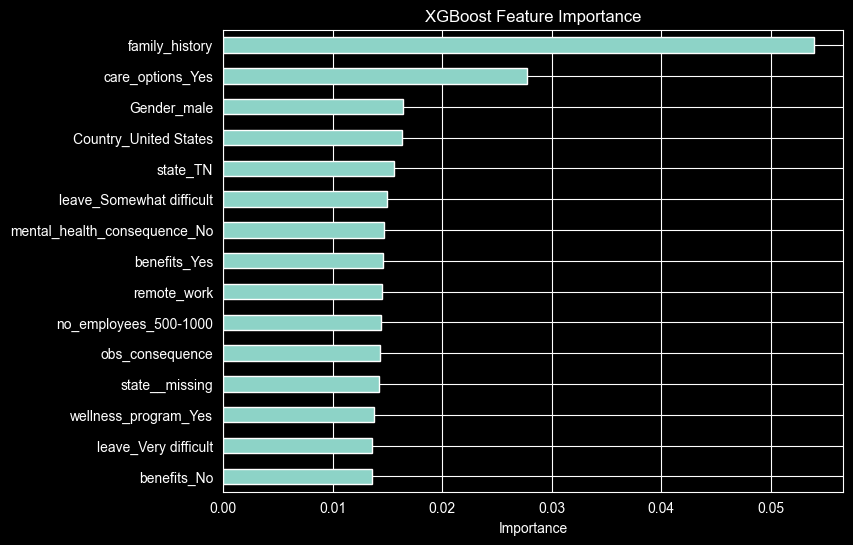

In [16]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

                         feature  importance_mean  importance_std
2                 family_history         0.092882        0.020063
110             care_options_Yes         0.039244        0.014323
129   mental_health_interview_No         0.027115        0.007140
126                coworkers_Yes         0.021758        0.014483
10                   Gender_male         0.020744        0.010863
8                 state__missing         0.020054        0.007841
0                            Age         0.018232        0.021944
107                  benefits_No         0.013475        0.008094
108                 benefits_Yes         0.012659        0.008912
130  mental_health_interview_Yes         0.010960        0.005658
64                      state_GA         0.010423        0.001018
54        Country_United Kingdom         0.010234        0.011104
132    phys_health_interview_Yes         0.009888        0.007574
4                   tech_company         0.009568        0.007499
17        

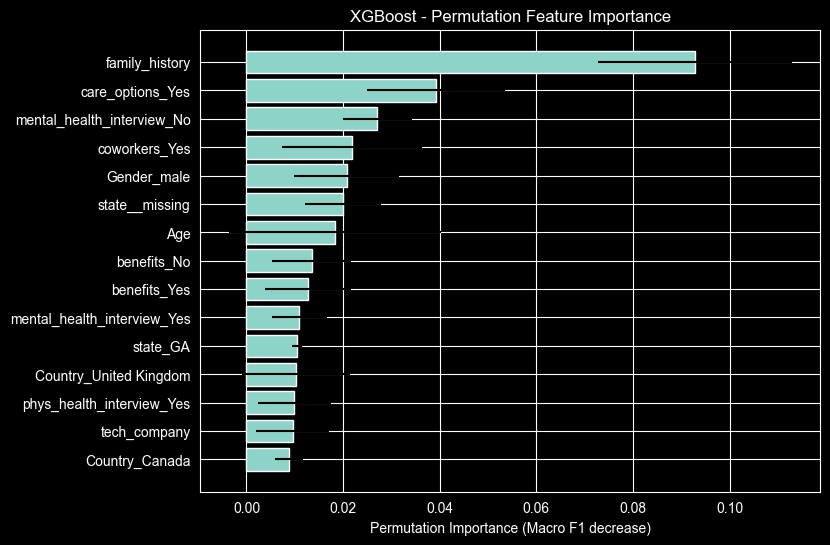

In [17]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_xgb_df.head(15))

top_features = perm_xgb_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("XGBoost - Permutation Feature Importance")
plt.show()

In [18]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,                # prevents overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.23      0.35      0.28        43
           1       0.51      0.57      0.53        88
           2       0.74      0.53      0.62       121

    accuracy                           0.51       252
   macro avg       0.49      0.48      0.48       252
weighted avg       0.57      0.51      0.53       252

Decision Tree Macro F1: 0.4751244438238502
Decision Tree Weighted F1: 0.529187398318537


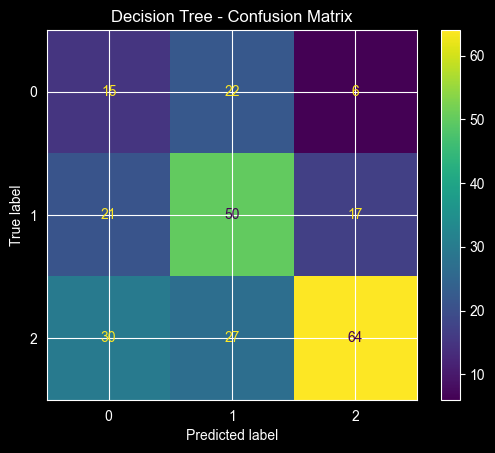

In [19]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_tree))

macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")
weighted_f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("Decision Tree Macro F1:", macro_f1_tree)
print("Decision Tree Weighted F1:", weighted_f1_tree)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

family_history                 0.277210
care_options_Yes               0.107448
Age                            0.080118
Country_United States          0.073203
phys_health_interview_Yes      0.047370
Gender_male                    0.046673
benefits_Yes                   0.037256
mental_vs_physical_No          0.032155
coworkers_Yes                  0.030354
no_employees_500-1000          0.025238
supervisor_Some of them        0.024174
anonymity_Yes                  0.022500
Country_Canada                 0.021577
mental_health_interview_Yes    0.019942
wellness_program_No            0.019213
dtype: float64


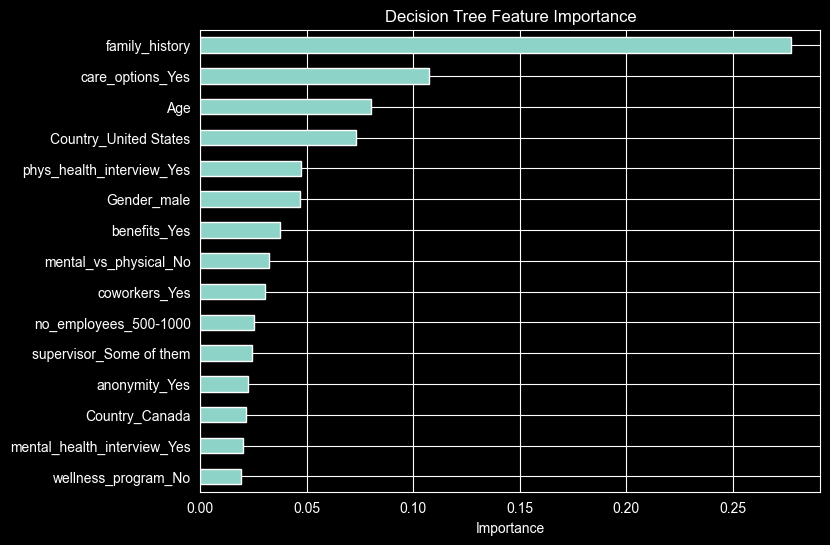

In [20]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(tree_importance.head(15))
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

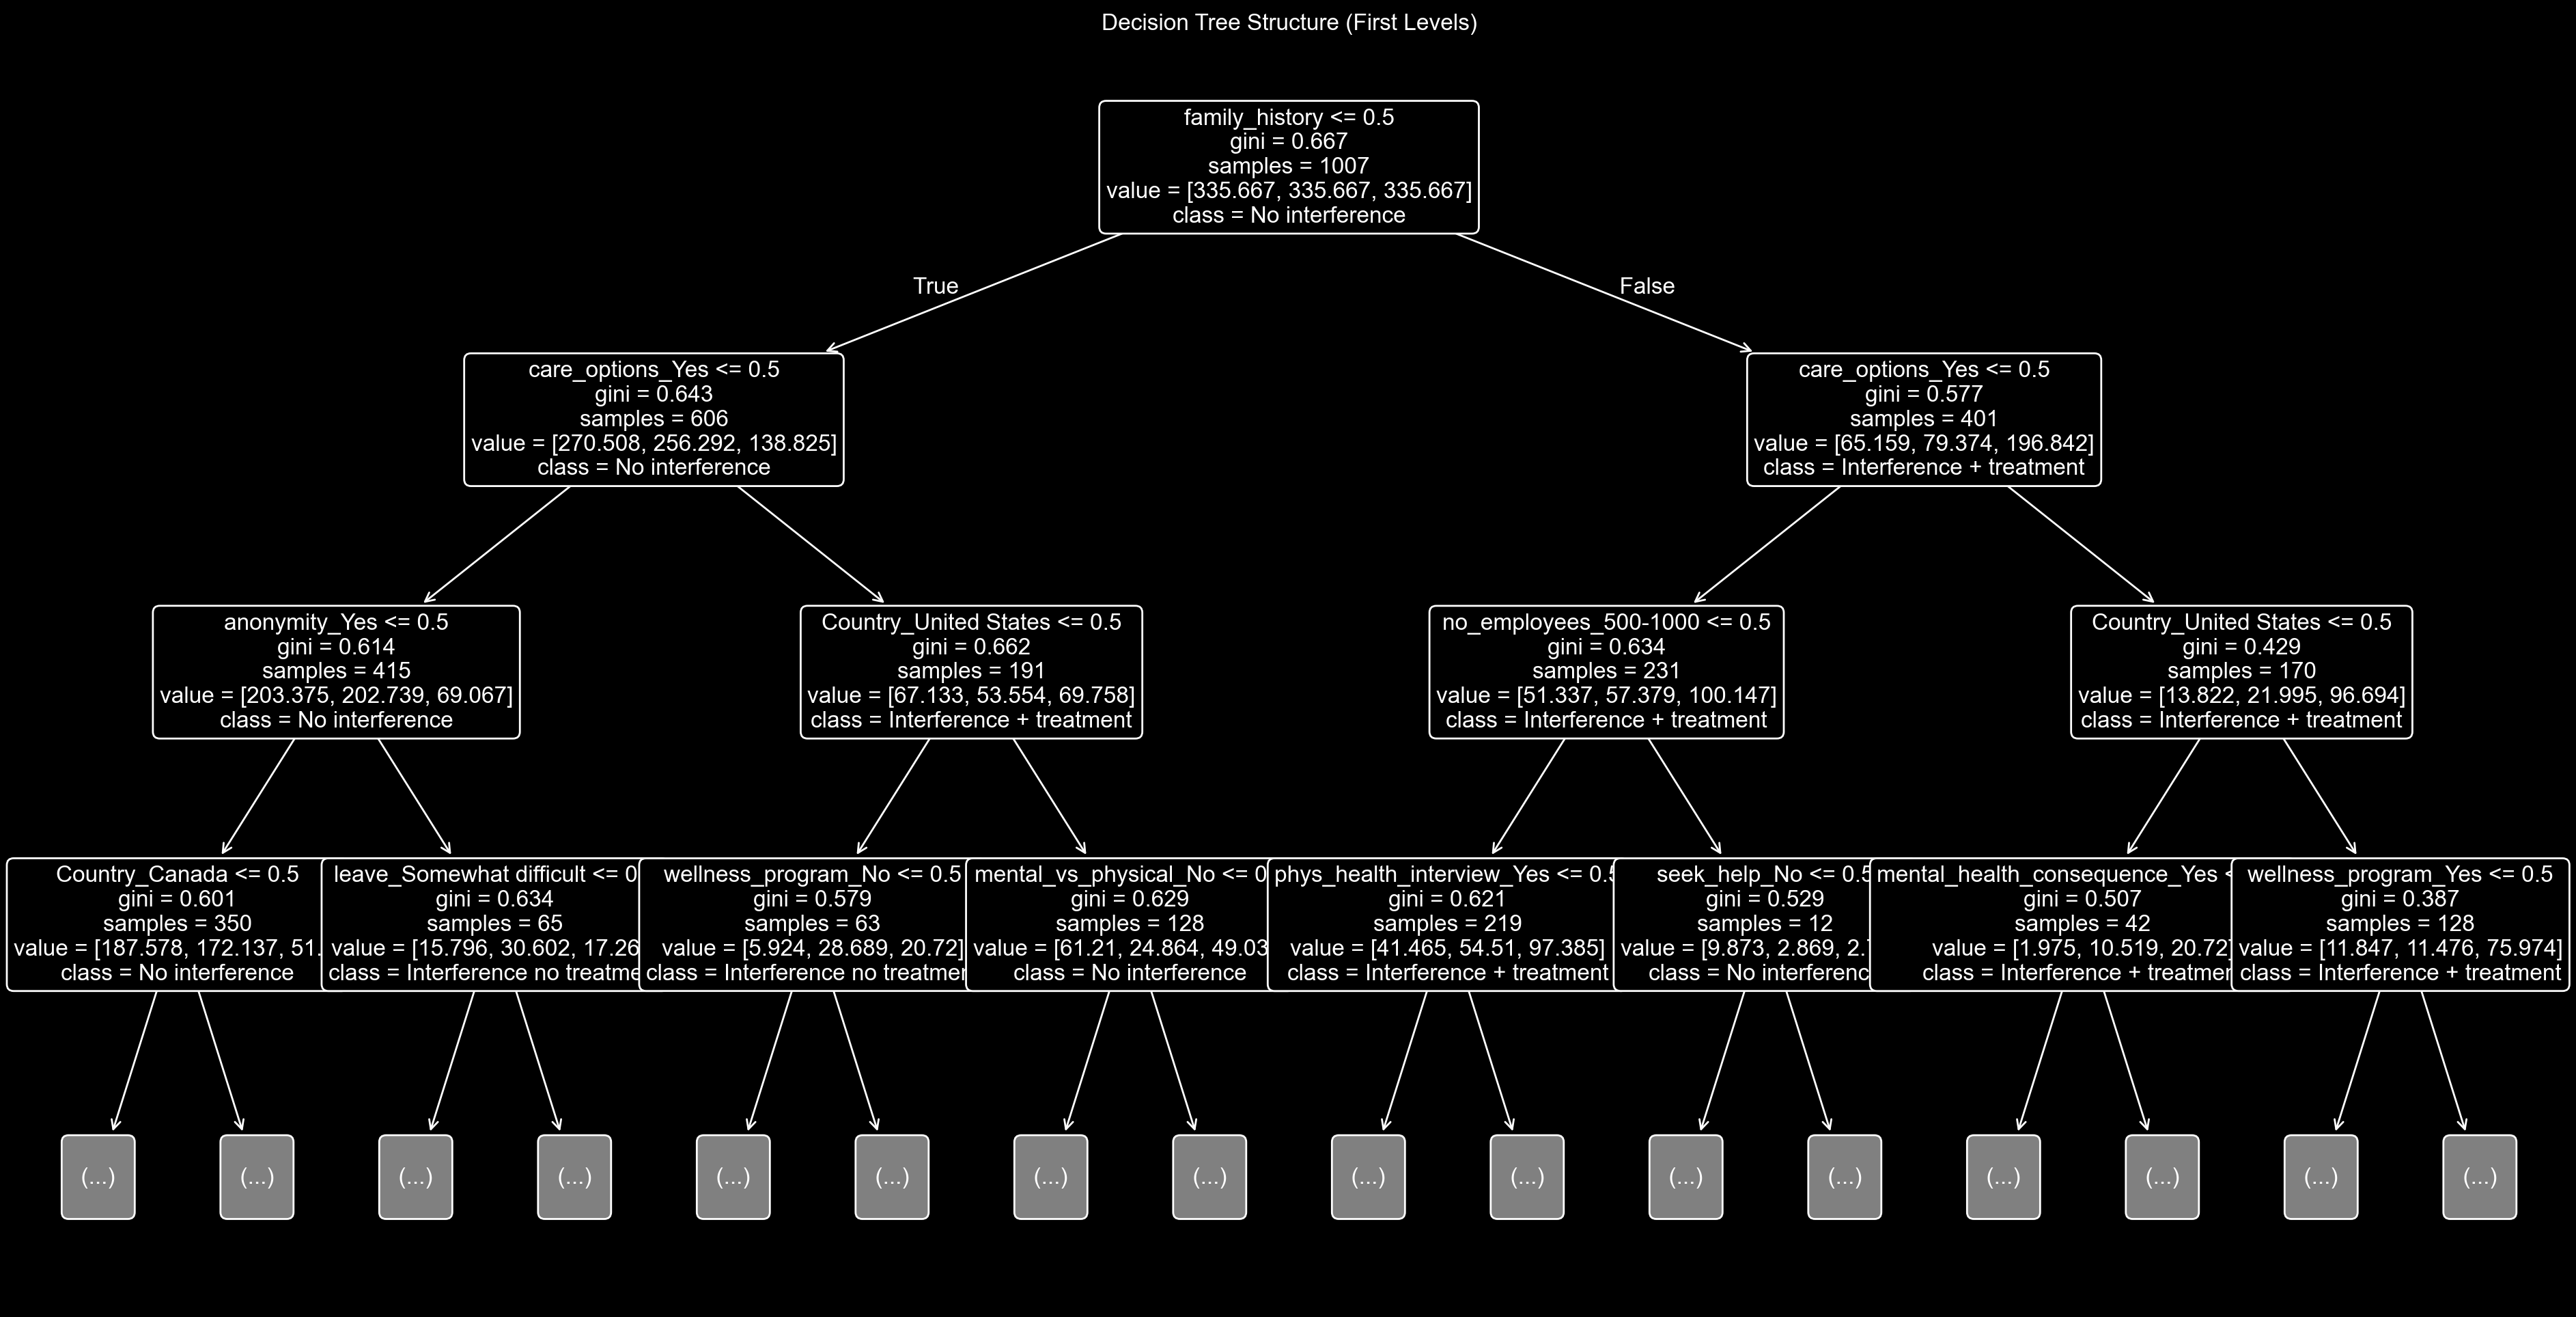

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12), dpi=200)

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No interference","Interference no treatment","Interference + treatment"],
    rounded=True,
    max_depth=3,
    fontsize=12
)

plt.title("Decision Tree Structure (First Levels)")
plt.show()

In [28]:
results = pd.DataFrame([
    {"Model": "Logistic Regression", "Macro F1": macro_f1, "Weighted F1": weighted_f1},
    {"Model": "Decision Tree", "Macro F1": macro_f1_tree, "Weighted F1": weighted_f1_tree},
    {"Model": "Random Forest", "Macro F1": macro_f1_rf, "Weighted F1": weighted_f1_rf},
    {"Model": "XGBoost", "Macro F1": macro_f1_xgb, "Weighted F1": weighted_f1_xgb}
])

print(results)

                 Model  Macro F1  Weighted F1
0  Logistic Regression  0.491190     0.552639
1        Decision Tree  0.475124     0.529187
2        Random Forest  0.509906     0.582942
3              XGBoost  0.542428     0.617192
